# Setup

📝 *Import required libraries and files:*

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import display, Markdown
import sys

In [35]:
path = "../assets/intermediate_dfs/df_raw.parquet"
raw_reviews = pd.read_parquet(path, engine="pyarrow") 

# 2.1. - Exploratory Data Analysis (EDA)

## 2.1.1. - Analysis of Variable's Distribution and Relation

In [ ]:
print(f"raw_reviews shape: {raw_reviews.shape}")
display(raw_reviews.head(3))

First, let's explore the distribution the variables to understand the information we have in the dataframe.

In [38]:
reviews = raw_reviews.copy()

### Total reviews and average score --> `app_name` and `score`

In [39]:
cols = ['app_name', 'score']

for col in cols:
    print(reviews[col].value_counts())
    print("-----------------------------------")

app_name
Barclays        265336
Revolut         262393
LLoyds          148653
Santander UK     80009
HSBC             38872
Monzo            22242
Name: count, dtype: int64
-----------------------------------
score
5    594535
1     99370
4     76299
3     25580
2     21721
Name: count, dtype: int64
-----------------------------------


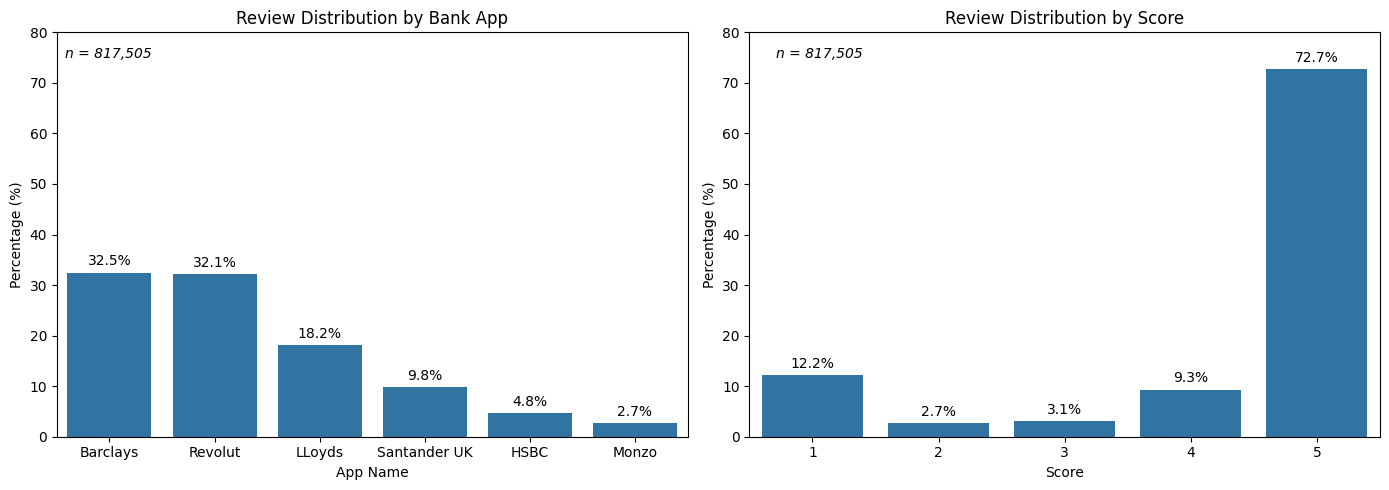

In [40]:
# Reusing earlier setup...
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compute percentage distributions
app_pct = (reviews['app_name'].value_counts(normalize=True) * 100).reset_index()
app_pct.columns = ['app_name', 'percentage']

score_pct = (reviews['score'].value_counts(normalize=True) * 100).sort_index().reset_index()
score_pct.columns = ['score', 'percentage']

# Plot 1: App Name
sns.barplot(data=app_pct, x='app_name', y='percentage', ax=axes[0])
axes[0].set_title('Review Distribution by Bank App')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xlabel('App Name')
axes[0].set_ylim(0, 80)
axes[0].set_yticks(range(0, 81, 10))
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%', label_type='edge', padding=3)

# Add total observation count
total_app = reviews['app_name'].notna().sum()
axes[0].annotate(f'n = {total_app:,}', xy=(0.4, 75), ha='right', fontsize=10, fontstyle='italic')

# Plot 2: Score
sns.barplot(data=score_pct, x='score', y='percentage', ax=axes[1])
axes[1].set_title('Review Distribution by Score')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xlabel('Score')
axes[1].set_ylim(0, 80)
axes[1].set_yticks(range(0, 81, 10))
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%', label_type='edge', padding=3)

# Add total observation count
total_score = reviews['score'].notna().sum()
axes[1].annotate(f'n = {total_score:,}', xy=(0.4, 75), ha='right', fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

**Number of reviews**: Barclays and Revolut account for a significative proportion of the reviews. However, in absolute terms even the bank with less reviews (i.e. Monzo) still has +22k reviews, which give us confidence to extract meaningfull insigts for each bank.

**Score**: Predominance of 5 scores. The second most frequent score is the score 1. This indicates that reviews tend to be given by customers in extreme (mostly positive, but also negative) scenarios.

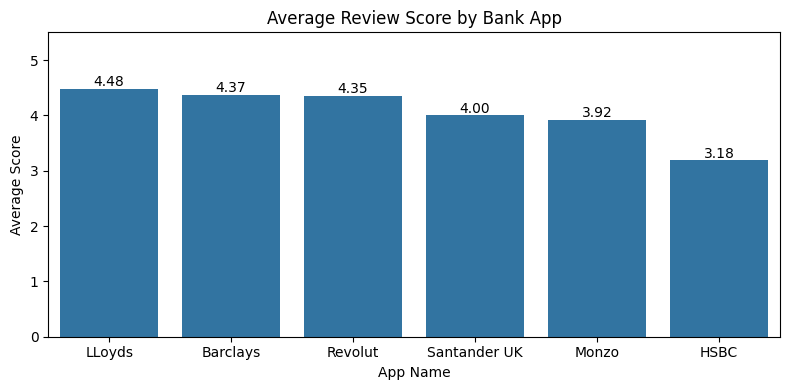

In [41]:
# Calculate average score per app
avg_score = (
    reviews.groupby('app_name')['score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=avg_score, x='app_name', y='score')

# Add value labels
for index, row in avg_score.iterrows():
    plt.text(x=index, y=row['score'] + 0.05, s=f"{row['score']:.2f}", ha='center', fontsize=10)

# Style
plt.title('Average Review Score by Bank App')
plt.xlabel('App Name')
plt.ylabel('Average Score')
plt.ylim(0, 5.5)
plt.yticks([0, 1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

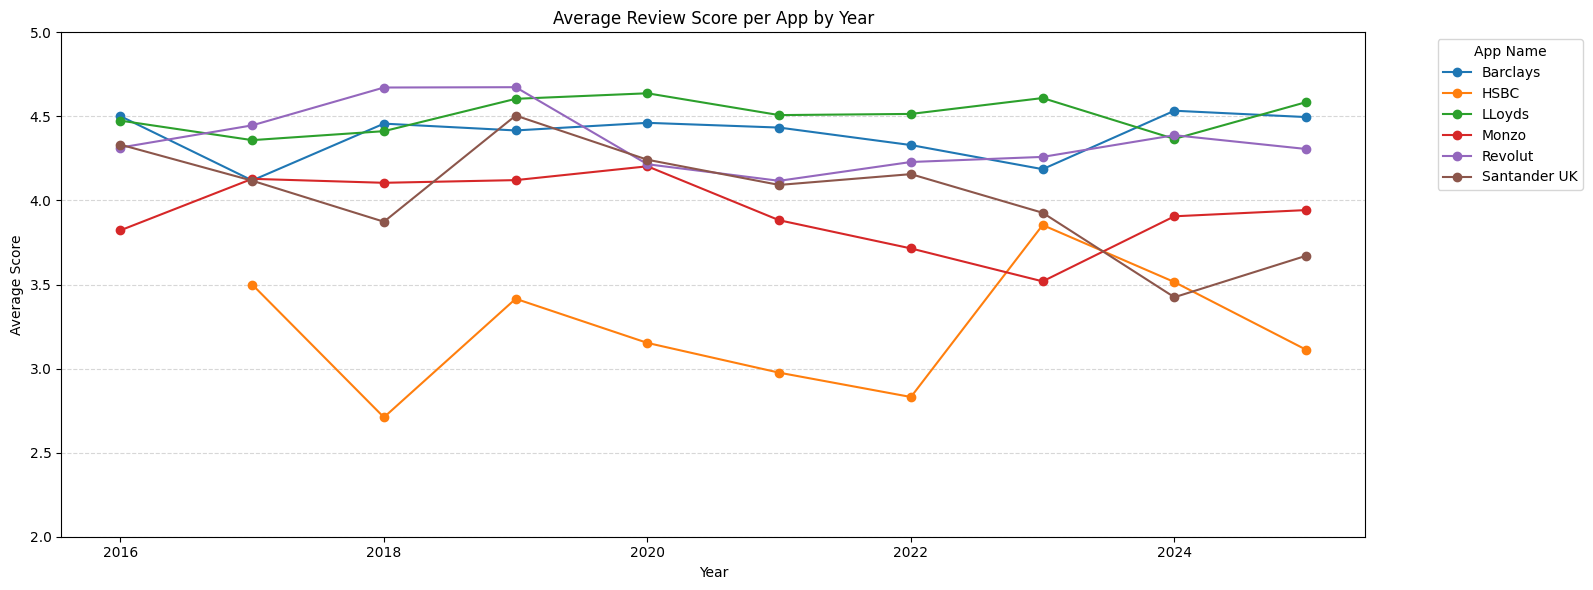

In [42]:
# Convert 'date' to datetime
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')

# Group by year and app_name, then calculate mean score
reviews['year'] = reviews['date'].dt.year
score_by_year_app = reviews.groupby(['year', 'app_name'])['score'].mean().reset_index()

# Filter to keep only years from 2016 onward
filtered_scores = score_by_year_app[score_by_year_app['year'] >= 2016]

# Pivot for plotting (years as x, apps as separate lines)
pivot_df = filtered_scores.pivot(index='year', columns='app_name', values='score')

# Plot
pivot_df.plot(marker='o', figsize=(16, 6))
plt.title('Average Review Score per App by Year')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.ylim(2, 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='App Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Thumbs up received --> `thumbs up`

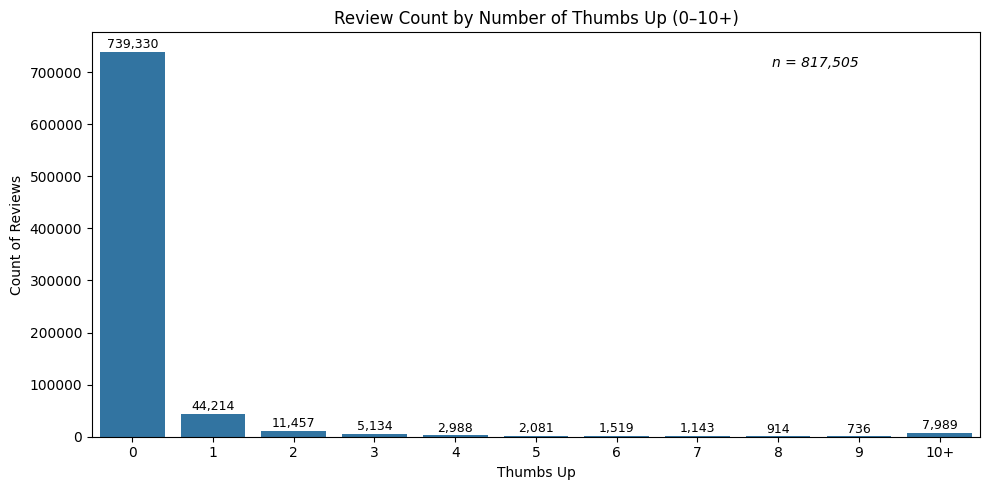

In [43]:
# Prepare thumbs_up count data
thumbs_counts_raw = reviews['thumbs_up'].value_counts().sort_index()

# Aggregate values >=10 into a "10+" bucket
thumbs_buckets = thumbs_counts_raw[thumbs_counts_raw.index <= 9].copy()
thumbs_buckets.loc[10] = thumbs_counts_raw[thumbs_counts_raw.index >= 10].sum()

# Convert to DataFrame
thumbs_counts = thumbs_buckets.reset_index()
thumbs_counts.columns = ['thumbs_up', 'count']

# Replace 10 with '10+'
thumbs_counts['thumbs_up'] = thumbs_counts['thumbs_up'].apply(lambda x: '10+' if x == 10 else str(x))

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=thumbs_counts, x='thumbs_up', y='count')

# Add count labels
for index, row in thumbs_counts.iterrows():
    plt.text(x=index, y=row['count'] + 7000, s=f"{row['count']:,}", ha='center', fontsize=9)

# Add total observation count
total_thumbs_up = raw_reviews['thumbs_up'].notna().sum()
plt.annotate(f'n = {total_thumbs_up:,}', xy=(9, 710000), ha='right', fontsize=10, fontstyle='italic')

# Style
plt.title('Review Count by Number of Thumbs Up (0–10+)')
plt.xlabel('Thumbs Up')
plt.ylabel('Count of Reviews')
plt.tight_layout()
plt.show()

**90% of the reviews did not receive any thumbs up** (i.e., 'likes').

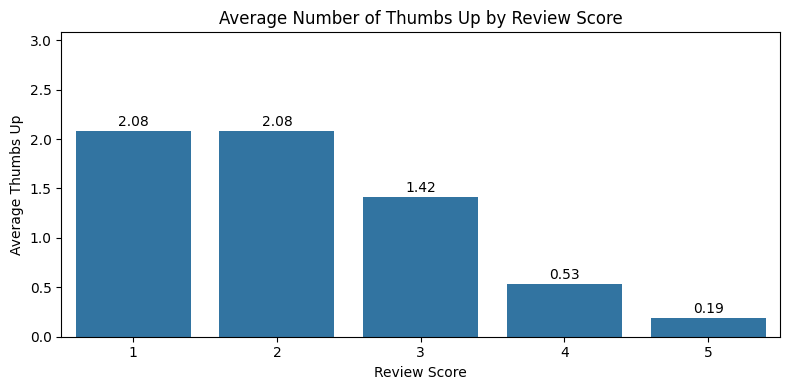

In [44]:
# Calculate average thumbs_up per score
avg_thumbs_by_score = (
    reviews.groupby('score')['thumbs_up']
    .mean()
    .reset_index()
    .sort_values('score')
)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=avg_thumbs_by_score, x='score', y='thumbs_up')

# Add value labels
for index, row in avg_thumbs_by_score.iterrows():
    plt.text(x=index, y=row['thumbs_up'] + 0.05, s=f"{row['thumbs_up']:.2f}", ha='center', fontsize=10)

# Style
plt.title('Average Number of Thumbs Up by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Thumbs Up')
plt.ylim(0, avg_thumbs_by_score['thumbs_up'].max() + 1)

plt.tight_layout()
plt.show()

**Average 'thumbs up' per score**: While the majority of the reviews have score 5 and have zero thumbs up, it is also clear from the graph above that **reviews with lower scores (score 1 and 2) have clearly more thumbs up on average than reviews with higher scores**. 

### Review Date --> `date`

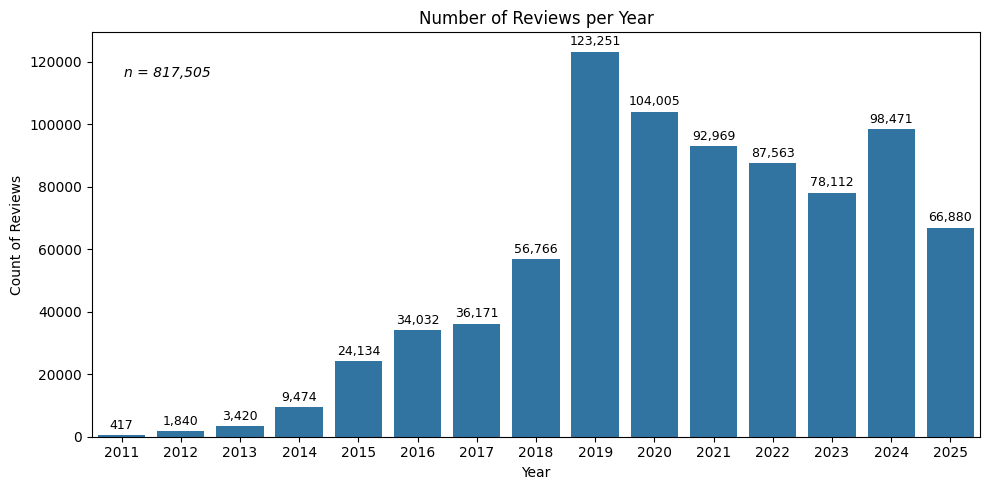

In [45]:
# Count number of reviews per year
reviews_by_year = (
    reviews['year']
    .value_counts()
    .sort_index()
    .reset_index()
)
reviews_by_year.columns = ['year', 'count']

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=reviews_by_year, x='year', y='count')

# Add value labels
for index, row in reviews_by_year.iterrows():
    plt.text(x=index, y=row['count'] + 2000, s=f"{row['count']:,}", ha='center', fontsize=9)

# Add total observation count
total_date = reviews['date'].notna().sum()
plt.annotate(f'n = {total_date:,}', xy=(1.5, 115000), ha='right', fontsize=10, fontstyle='italic')

# Style
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Count of Reviews')
plt.tight_layout()
plt.show()

In [46]:
last_review = reviews['date'].max()
print(f"Date of the last review existent in the dataframe: {last_review}")

Date of the last review existent in the dataframe: 2025-10-05 10:25:42


⚠️**Warning**: These values might not reflect user activity but rather data availability. Sometimes APIs or scrapers capture more recent reviews better than older ones.

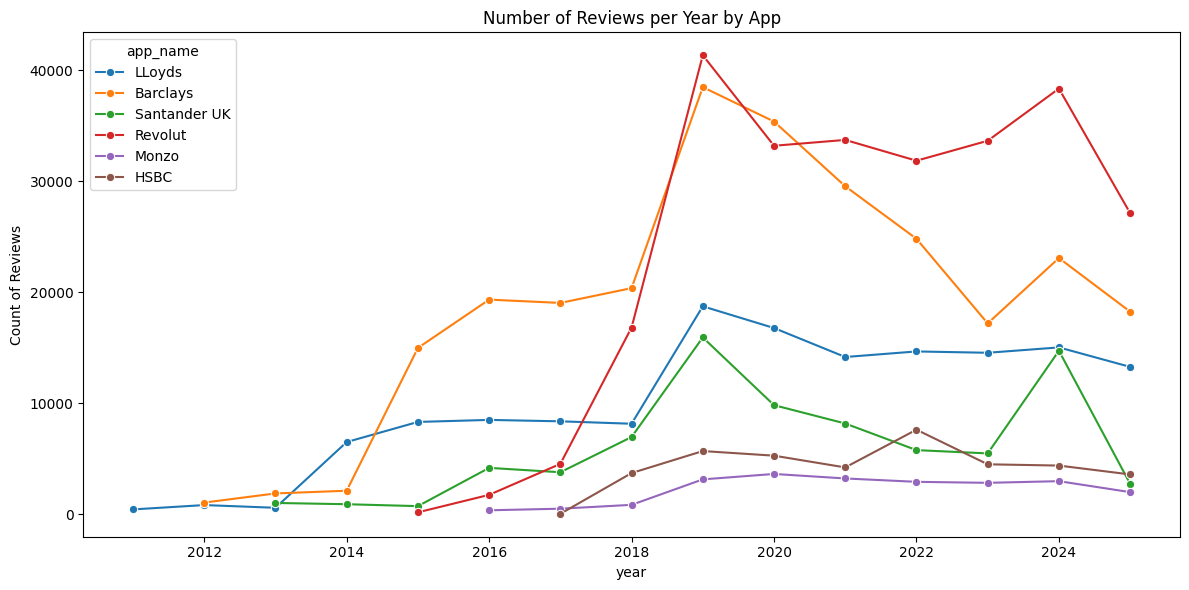

In [47]:
reviews_by_year_app = reviews.groupby(['year', 'app_name']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=reviews_by_year_app, x='year', y='count', hue='app_name', marker='o')
plt.title('Number of Reviews per Year by App')
plt.ylabel('Count of Reviews')
plt.tight_layout()
plt.show()

While some differences exist (e.g., Revolut had a particularly strong spike in the reviews in 2019) the **trend is relatively consistent across players**, with a strong increase in the reviews in 2019 and a gradual decline until 2024 when it increased again (while not reaching 2019 values).

### Replies --> 'reply' and 'Reply_Date'

In [48]:
print(f"Number of reviews with reply: {reviews['Reply'].notna().sum()}")
print("----------------------------------------")
print(f"Number of reviews without reply: {reviews['Reply'].isna().sum()}")

Number of reviews with reply: 112115
----------------------------------------
Number of reviews without reply: 705390


In [49]:
reviews['Replied'] = reviews['Reply'].notna().astype('int8')
reviews.head(3)

,app_name,user_name,score,text,date,thumbs_up,Reply,Reply_Date,App_Version,year,Replied
0,Santander UK,A Google user,1,Cheque scanner used to work.. Now the boundary...,2025-10-04 21:33:19,0,Sorry to hear this. If you continue to have is...,2025-10-05 08:23:13,5.26.0,2025,1
1,Santander UK,A Google user,5,I changed to 5 stars after bringing back a fun...,2025-10-04 15:19:55,0,"Thanks for this, appreciate the review and the...",2025-10-04 15:24:00,5.26.0,2025,1
2,Santander UK,A Google user,5,easy to use simple to do what's needed can't a...,2025-10-04 12:47:59,0,Thanks for the great review Dale! ^NB,2025-10-04 12:53:04,5.26.0,2025,1


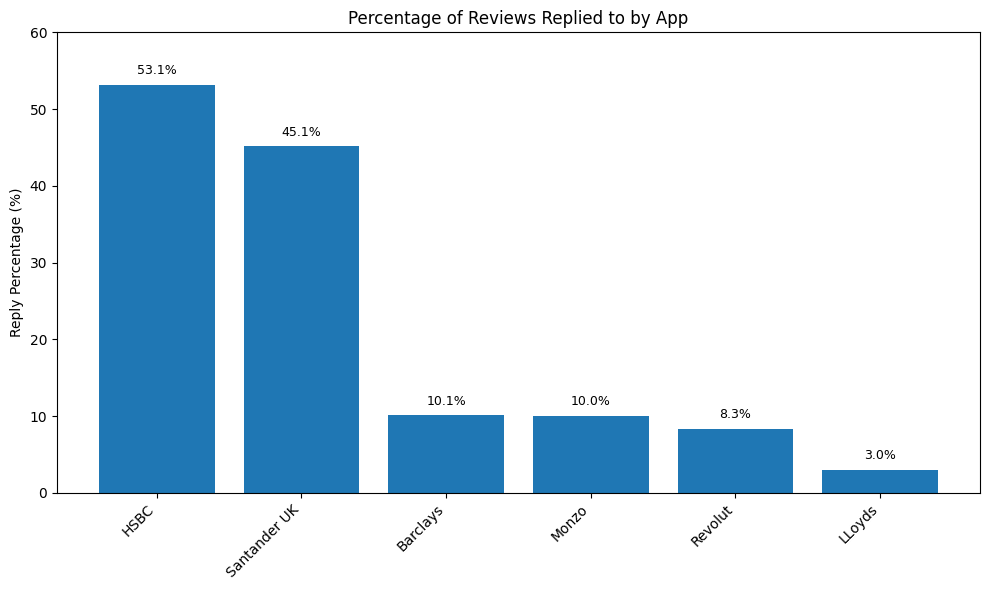

In [50]:
# Group by app and calculate reply stats
reply_stats = reviews.groupby('app_name').agg(
    total_reviews=('Replied', 'count'),
    replied_reviews=('Replied', 'sum')
)

# Compute reply percentage
reply_stats['reply_percentage'] = (reply_stats['replied_reviews'] / reply_stats['total_reviews']) * 100

# Sort by reply percentage
reply_stats = reply_stats.sort_values(by='reply_percentage', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(reply_stats.index, reply_stats['reply_percentage'])

# Add labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,  # slightly above the bar
        f'{height:.1f}%',  # format to 1 decimal place
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel('Reply Percentage (%)')
plt.ylim(0, 60)
plt.title('Percentage of Reviews Replied to by App')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There is substantial difference in the percentage of replied reviews between the banking players. **While HSBC and Santander frequently reply to their reviews, the remaining banks reply to a small portion of the reviews**.

Let's also **analyze the `time_to_reply_hours`** in those situations that a reply was given, by comparing `date` with `Reply_Date` and converting the difference into hours.

In [51]:
reviews['Reply_Date'] = pd.to_datetime(reviews['Reply_Date'])
reviews['time_to_reply'] = reviews['Reply_Date']-reviews['date']
reviews['time_to_reply_hours'] = (reviews['time_to_reply'].dt.total_seconds() / 3600).round(2) # convert seconds to hours (60 * 60)
reviews.drop('time_to_reply', axis=1, inplace=True)

Since some reviews have `Reply_Date` previous to `date` of the review, which is logically impossible, in order to analyse the times to reply we will remove all those situations. This abnormal dates may be caused by inconsistent timestamps

In [52]:
no_error_date = reviews[reviews['time_to_reply_hours']>0]
print(no_error_date.shape)

(101861, 12)


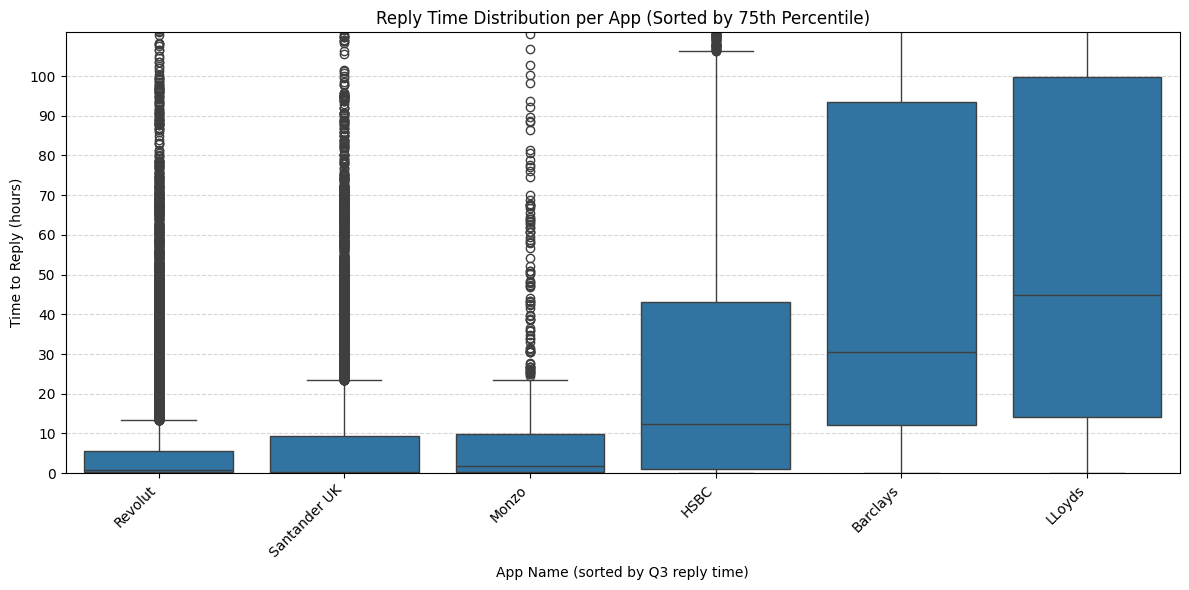

In [53]:
# Filter for valid replies
replied_reviews = no_error_date[no_error_date['Replied'] == 1]

# Calculate Q3 (75th percentile) per app
q3_per_app = (
    replied_reviews
    .groupby('app_name')['time_to_reply_hours']
    .quantile(0.75)
    .sort_values()
)

# Reorder the 'app_name' column based on Q3
replied_reviews['app_name'] = pd.Categorical(
    replied_reviews['app_name'],
    categories=q3_per_app.index,
    ordered=True
)

# Plot the boxplot with custom app order
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=replied_reviews,
    x='app_name',
    y='time_to_reply_hours',
    showfliers=True
)
plt.xlabel('App Name (sorted by Q3 reply time)')
plt.ylabel('Time to Reply (hours)')
plt.title('Reply Time Distribution per App (Sorted by 75th Percentile)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 111)
plt.yticks(range(0, 110, 10))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

While we've seen before that HSBC outperformed others when it came to % of reviews that were replied, in what concerns the time it took to reply, Revolut, Santander and Monzo clearly outperform others.

75% of the replies given by **Revolut, Santander and Monzo** took **less than 10 hours** versus the time of the review. This value increases to aproximately **45 hours in HSBC** and is **more than 90 hours for Barclays and LLoyds**.



### User Name --> `user_name`

We've seen that many of the user_name values have value 'A Google user'. Let's understand which is the percentage of rows with identifiable users, to evaluate the added value of this column:

In [54]:
no_user = ((reviews['user_name'] == 'A Google user').sum()) / len(reviews) * 100
print(f"Percentage of rows without User information: {no_user:.2f}%")

Percentage of rows without User information: 99.43%


Less than 1% of the reviews have an identified username, making this information irrelevant for the purpose of this project. `user_name` will be droped.

### App Versions --> `app_version`

Let's analyze the number of unique `App_Version` for each bank:

In [55]:
print(reviews.groupby('app_name')['App_Version'].nunique())
print(reviews.groupby('app_name')['App_Version'].nunique().sum())

app_name
Barclays        195
HSBC            103
LLoyds          179
Monzo           480
Revolut         760
Santander UK    100
Name: App_Version, dtype: int64
1817


There is an incredible amount of different app versions during the period of analysis, ranging from 99 different app versions for Santander UK to +750 versions for Revolut.

Let's check if we can quickly break the smaller version changes into larger "macro versions" of the App by splitting the `App_Version` string:

In [56]:
# Split 'App_Version' into two parts: before and after the first dot
version_split = reviews['App_Version'].astype(str).str.split('.', n=1, expand=True)

# Assign to new columns
reviews['version_macro'] = version_split[0]
reviews['version_detail'] = version_split[1]

# If there's no dot, move the value to 'version_detail' and set 'version_macro' as NaN
mask_no_dot = ~reviews['App_Version'].astype(str).str.contains('.')
reviews.loc[mask_no_dot, 'version_macro'] = pd.NA
reviews.loc[mask_no_dot, 'version_detail'] = reviews.loc[mask_no_dot, 'App_Version']

In [57]:
print(reviews.groupby('app_name')['version_macro'].nunique())
print(reviews.groupby('app_name')['version_macro'].nunique().sum())

app_name
Barclays          4
HSBC              3
LLoyds          142
Monzo             8
Revolut          11
Santander UK      6
Name: version_macro, dtype: int64
174


Using the new approach, we observe a significant drop in the number of versions, with exception of LLoyds that seems to have a different app version categorization format.

⚠️ Further analysis on `app_versions` could be made to clean app version data from LLoyds, but, as for now, we will keep it as it is and devote extra time to this only if a specific use case for app version appears. 

# 2.2. - Data Cleaning

Now we will create cleaned df using a function `cleaning` that encapsulates all the needs we've identified in this notebook to prepare the dataframe for further sentiment and topic modeling analysis.

In [58]:
raw_reviews.shape

(817505, 9)

In [59]:
raw_reviews.head(2)

,app_name,user_name,score,text,date,thumbs_up,Reply,Reply_Date,App_Version
0,Santander UK,A Google user,1,Cheque scanner used to work.. Now the boundary...,2025-10-04 21:33:19,0,Sorry to hear this. If you continue to have is...,2025-10-05 08:23:13,5.26.0
1,Santander UK,A Google user,5,I changed to 5 stars after bringing back a fun...,2025-10-04 15:19:55,0,"Thanks for this, appreciate the review and the...",2025-10-04 15:24:00,5.26.0


In [ ]:
def cleaning(df_raw: pd.DataFrame):
    """
    Clean raw Google Play reviews into a consistent schema. 
    Removes reviews prior to date 2017-01-01.
    """
    df = df_raw.copy()

    # Drop columns we don't keep
    df = df.drop(columns = ['user_name'])
    
    # Create sequential review_id starting at 1
    df.insert(0, 'review_id', np.arange(1, 1 + len(df), dtype='int32'))

    # Parse date columns
    for c in ['date', 'Reply_Date']:
        df[c] = pd.to_datetime(df[c], errors='coerce')
    
    # Create column 'year'
    df['year'] = df['date'].dt.year.astype('Int16')
    
    # Create column 'replied' where 1 means replied and 0 means not replied
    df['replied'] = reviews['Reply'].notna().astype('int8')
    
    # Create 'time_to_reply(h)'
    delta = df['Reply_Date'] - df['date']
    df['time_to_reply(h)'] = (delta.dt.total_seconds() / 3600).round(2)
    
    # Split 'app_version''app_version_head','app_version_detail'
    vs = df['App_Version'].astype(str).str.split('.', n=1, expand=True)
    df['app_version_head'] = vs[0]
    df['app_version_detail'] = vs[1]
    
    # rows with no '.' → put the whole value in version_detail, macro = NA
    no_dot = ~df['App_Version'].astype(str).str.contains('.', regex=False)
    df.loc[no_dot, 'app_version_head'] = pd.NA
    df.loc[no_dot, 'app_version_detail'] = df.loc[no_dot, 'App_Version']
    # drop legacy column after splitting
    df = df.drop(columns=['App_Version'])
    
    # Rename columns
    colmap = {
        'app_name': 'app',
        'text': 'review_text',
        'date': 'review_date',
        'Reply': 'reply_text',
        'Reply_Date': 'reply_date',
    }
    df = df.rename(columns=colmap)
    
    # --- text cleaning (creates *_clean) ---
    def _clean_text(x):
        if not isinstance(x, str):
            return pd.NA
        t = x.lower()                                # lowercase
        t = re.sub(r"http\S+", "", t)                # remove URLs
        t = re.sub(r"\s+", " ", t).strip()           # normalize whitespace
        return t if t else pd.NA

    df['review_text_clean'] = df['review_text'].map(_clean_text)
    
    df['reply_text_clean']  = df['reply_text'].map(_clean_text)

    # Drop reviews prior to 2018-01-01
    df = df.loc[df["review_date"] >= pd.Timestamp("2018-01-01")].copy()
    
    # Reorder columns; keep any others at the end
    new_order = [
        'review_id', 'app', 'score','review_text','review_text_clean','review_date','year','thumbs_up','replied','reply_text',
        'reply_text_clean','reply_date','time_to_reply(h)','app_version_head','app_version_detail'
    ]

    df = df[new_order]

    # --- Save Final Dataframe ---
    save_path = "../assets/intermediate_dfs/df_clean.parquet"
    df.to_parquet(save_path, index = False)
    print(f"✅ Dataframe saved in {save_path}")

    return df

In [61]:
df_clean = cleaning (raw_reviews)
print (df_clean.shape)
display(df_clean.head(2))

✅ Dataframe saved in ../assets/intermediate_dfs/df_clean.parquet
(708017, 15)


,review_id,app,score,review_text,review_text_clean,review_date,year,thumbs_up,replied,reply_text,reply_text_clean,reply_date,time_to_reply(h),app_version_head,app_version_detail
0,1,Santander,1,Cheque scanner used to work.. Now the boundary...,cheque scanner used to work.. now the boundary...,2025-10-04 21:33:19,2025,0,1,Sorry to hear this. If you continue to have is...,sorry to hear this. if you continue to have is...,2025-10-05 08:23:13,10.83,5,26.0
1,2,Santander,5,I changed to 5 stars after bringing back a fun...,i changed to 5 stars after bringing back a fun...,2025-10-04 15:19:55,2025,0,1,"Thanks for this, appreciate the review and the...","thanks for this, appreciate the review and the...",2025-10-04 15:24:00,0.07,5,26.0
